In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import lightgbm as lgb
import xgboost as xgb
import warnings

from typing import Dict, List, Optional, Tuple
from sklearn.base import BaseEstimator, TransformerMixin
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
from helper import FeatureEngineering, columns_init_to_drop

In [26]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class FeatureEngineering(BaseEstimator, TransformerMixin):
    """Leakage-safe feature engineering transformer for customer churn prediction.

    All statistics used for feature engineering are learned during fit() using
    training data only, then reused during transform().
    """

    def __init__(self, drop_cols=None):
        self.medians_ = {}
        self.drop_cols = drop_cols or []

    def fit(self, X, y=None):
        """Learn statistics required for feature engineering from training data only."""
        X = X.copy()

        median_columns = [
            "satisfaction_score",
            "monthly_charge",
            "data_usage_gb",
            "streaming_hours_monthly",
            "tenure_months",
            "device_age_months",
        ]

        for col in median_columns:
            if col in X.columns:
                self.medians_[col] = X[col].median()

        return self

    def transform(self, X):
        """Apply feature engineering using statistics learned during fit()."""
        df = X.copy()

        df = self.create_customer_health_score(df)
        df = self.create_risk_segments(df)
        df = self.create_interaction_features(df)
        df = self.create_recency_features(df)
        df = self.create_binned_features(df)
        df = self.create_usage_features(df)

        if self.drop_cols:
            existing_cols = [c for c in self.drop_cols if c in df.columns]
            df = df.drop(columns=existing_cols)

        return df

    # --------------------------------------------------
    # CUSTOMER HEALTH
    # --------------------------------------------------

    def create_customer_health_score(self, df):
        """Create customer health and satisfaction/network features."""
        if {"satisfaction_score", "support_calls_90d"}.issubset(df.columns):
            sat_median = self.medians_.get(
                "satisfaction_score", df["satisfaction_score"].median()
            )
            sat = df["satisfaction_score"].fillna(sat_median)
            calls = df["support_calls_90d"].fillna(0)

            df["customer_health_score"] = sat * 20 - calls * 2

        if {"satisfaction_score", "network_complaints"}.issubset(df.columns):
            sat_median = self.medians_.get(
                "satisfaction_score", df["satisfaction_score"].median()
            )
            sat = df["satisfaction_score"].fillna(sat_median)
            complaints = df["network_complaints"].fillna(0)

            df["satisfaction_network_ratio"] = sat / (complaints + 1)

        return df

    # --------------------------------------------------
    # RISK FEATURES
    # --------------------------------------------------

    def create_risk_segments(self, df):
        """Create payment, support, and network risk features.

        Missing source values remain missing instead of being silently converted
        into the lowest-risk category.
        """
        if "payment_delay_days" in df.columns:
            df["payment_delay_risk"] = pd.cut(
                df["payment_delay_days"],
                bins=[-np.inf, 0.5, 2.5, np.inf],
                labels=False,
            )

            df["has_payment_delay"] = np.where(
                df["payment_delay_days"].isna(),
                np.nan,
                (df["payment_delay_days"] > 0).astype(float),
            )

        if "support_calls_90d" in df.columns:
            df["support_risk"] = pd.cut(
                df["support_calls_90d"],
                bins=[-np.inf, 0, 1, 3, np.inf],
                labels=False,
            )

            df["high_support_risk"] = np.where(
                df["support_calls_90d"].isna(),
                np.nan,
                (df["support_calls_90d"] >= 3).astype(float),
            )

        if "network_complaints" in df.columns:
            df["network_risk"] = pd.cut(
                df["network_complaints"],
                bins=[-np.inf, 0, 2, 5, np.inf],
                labels=False,
            )

        return df

    # --------------------------------------------------
    # INTERACTION FEATURES
    # --------------------------------------------------

    def create_interaction_features(self, df):
        """Create business-related interaction features."""
        if {"number_of_services", "monthly_charge"}.issubset(df.columns):
            services = df["number_of_services"].fillna(0)
            charge_median = self.medians_.get(
                "monthly_charge", df["monthly_charge"].median()
            )
            charge = df["monthly_charge"].fillna(charge_median)

            df["charge_per_service"] = charge / (services + 1)

        if {"data_usage_gb", "streaming_hours_monthly"}.issubset(df.columns):
            usage_median = self.medians_.get(
                "data_usage_gb", df["data_usage_gb"].median()
            )
            usage = df["data_usage_gb"].fillna(usage_median)

            hours_median = self.medians_.get(
                "streaming_hours_monthly",
                df["streaming_hours_monthly"].median(),
            )
            hours = df["streaming_hours_monthly"].fillna(hours_median)

            df["data_streaming_interaction"] = usage * hours

        if {"support_calls_90d", "network_complaints"}.issubset(df.columns):
            calls = df["support_calls_90d"].fillna(0)
            complaints = df["network_complaints"].fillna(0)

            df["support_network_interaction"] = calls * complaints

        if {"payment_delay_days", "late_payment_count"}.issubset(df.columns):
            delay = df["payment_delay_days"].fillna(0)
            count = df["late_payment_count"].fillna(0)

            df["payment_risk_interaction"] = delay * count

        return df

    # --------------------------------------------------
    # RECENCY / LIFETIME FEATURES
    # --------------------------------------------------

    def create_recency_features(self, df):
        """Create device-age and lifetime-value related features."""
        if {"tenure_months", "device_age_months"}.issubset(df.columns):
            tenure_median = self.medians_.get(
                "tenure_months", df["tenure_months"].median()
            )
            tenure = df["tenure_months"].fillna(tenure_median)

            dev_median = self.medians_.get(
                "device_age_months", df["device_age_months"].median()
            )
            device_age = df["device_age_months"].fillna(dev_median)

            df["device_age_vs_tenure"] = device_age / (tenure + 1)

        if {"lifetime_spend", "tenure_months"}.issubset(df.columns):
            tenure_median = self.medians_.get(
                "tenure_months", df["tenure_months"].median()
            )
            tenure = df["tenure_months"].fillna(tenure_median)
            spend = df["lifetime_spend"].fillna(0)

            df["monthly_lifetime_value"] = spend / (tenure + 1)

        return df

    # --------------------------------------------------
    # BIN FEATURES
    # --------------------------------------------------

    def create_binned_features(self, df):
        """Create predefined business/data-driven bins.

        Missing values in the original feature remain missing in the
        corresponding bin feature.
        """
        if "tenure_months" in df.columns:
            df["tenure_months_bin"] = pd.cut(
                df["tenure_months"],
                bins=[-np.inf, 2.5, 7.5, 11.5, 23.5, 38.5, np.inf],
                labels=False,
            )

        if "monthly_charge" in df.columns:
            df["monthly_charge_bin"] = pd.cut(
                df["monthly_charge"],
                bins=[
                    -np.inf,
                    38.625,
                    40.705,
                    43.445,
                    58.235,
                    68.605,
                    np.inf,
                ],
                labels=False,
            )

            df["monthly_charge_cat_lmh"] = pd.cut(
                df["monthly_charge"],
                bins=[-np.inf, 35, 65, np.inf],
                labels=["Low", "Medium", "High"],
            )

        if "age" in df.columns:
            df["age_bin"] = pd.cut(
                df["age"],
                bins=[-np.inf, 19.5, 29.5, 64.5, np.inf],
                labels=False,
            )

        if "data_usage_gb" in df.columns:
            df["data_usage_gb_bin"] = pd.cut(
                df["data_usage_gb"],
                bins=[
                    -np.inf,
                    7.225,
                    8.415,
                    15.545,
                    21.915,
                    34.745,
                    np.inf,
                ],
                labels=False,
            )

        if "streaming_hours_monthly" in df.columns:
            df["streaming_hours_monthly_bin"] = pd.cut(
                df["streaming_hours_monthly"],
                bins=[-np.inf, 6.45, 15.65, 22.25, 32.65, 127.35, np.inf],
                labels=False,
            )

        if "device_age_months" in df.columns:
            df["device_age_months_bin"] = pd.cut(
                df["device_age_months"],
                bins=[-np.inf, 2.5, 3.5, 8.5, 31.5, 39.5, np.inf],
                labels=False,
            )

        if "app_sessions_weekly" in df.columns:
            df["app_sessions_weekly_bin"] = pd.cut(
                df["app_sessions_weekly"],
                bins=[-np.inf, 2.5, 11.5, 13.5, 18.5, 21.5, np.inf],
                labels=False,
            )

        if {"app_sessions_weekly", "satisfaction_score"}.issubset(df.columns):
            valid = (
                df["app_sessions_weekly"].notna()
                & df["satisfaction_score"].notna()
            )

            df["danger_zone"] = np.where(
                valid,
                (
                    (df["app_sessions_weekly"] < 5)
                    & (df["satisfaction_score"] < 5)
                ).astype(float),
                np.nan,
            )

        if {"lifetime_spend", "monthly_charge"}.issubset(df.columns):
            spend = df["lifetime_spend"].fillna(0)
            charge_median = self.medians_.get(
                "monthly_charge", df["monthly_charge"].median()
            )
            charge = df["monthly_charge"].fillna(charge_median)

            df["lf_calculated_tenure_months"] = spend / (charge + 1e-5)

        if "late_payment_count" in df.columns:
            df["late_payment_group"] = (
                df["late_payment_count"]
                .fillna(0)
                .clip(upper=3)
                .astype(int)
            )

        if "discount_percentage" in df.columns:
            df["discount_tier"] = pd.cut(
                df["discount_percentage"],
                bins=[-np.inf, 0, 10, 25, np.inf],
                labels=["0%(NoDiscount)", "1-10%", "11-25%", "25%+"],
            )

        return df

    # --------------------------------------------------
    # USAGE FEATURES
    # --------------------------------------------------

    def create_usage_features(self, df):
        """Create usage-related transformations."""
        if "average_session_minutes" in df.columns:
            df["average_session_log"] = np.log1p(
                df["average_session_minutes"].clip(lower=0)
            )

        if {"app_sessions_weekly", "average_session_minutes"}.issubset(
            df.columns
        ):
            sessions = df["app_sessions_weekly"].fillna(0)
            avg_minutes = df["average_session_minutes"].fillna(0)

            df["total_weekly_minutes"] = sessions * avg_minutes

        return df

    def drop_columns_init(self, df: pd.DataFrame, drop_cols: list) -> pd.DataFrame:
        df = df.copy()
        # Drop only columns that actually exist in the dataframe to prevent KeyError
        existing_drop_cols = [col for col in drop_cols if col in df.columns]
        print("Before Shape:", df.shape)
        df = df.drop(columns=existing_drop_cols)
        print("After Shape:", df.shape)
        return df



columns_init_to_drop = ['customer_id','tenure_months','satisfaction_score','monthly_charge','age','data_usage_gb','streaming_hours_monthly',
           'payment_delay_days','late_payment_count','discount_percentage','support_calls_90d','app_sessions_weekly',
           'average_session_minutes']

as_it_is = ['number_of_services','average_session_minutes','network_complaints','referral_count','referral_count']
log = ['average_session_minutes']



In [2]:
train = pd.read_csv("novatel-customer-intelligence/train.csv")
test = pd.read_csv("novatel-customer-intelligence/test.csv")


In [27]:
# Initialize feature engineering
fe = FeatureEngineering()

df_engineered = fe.fit_transform(X=train)
df_engineered = fe.drop_columns_init(df_engineered,columns_init_to_drop)
feature_list = df_engineered.columns
print("\n📊 FEATURE SUMMARY")
print("=" * 60)
print(f"Original features: {len(train.columns)}")
print(f"Engineered features: {len(feature_list)}")
print(f"Final dataset shape: {df_engineered.shape}")

# Save engineered dataset
df_engineered.to_csv('train_engineered.csv', index=False)
print("\n✅ Engineered dataset saved to: train_engineered.csv")

Before Shape: (12000, 62)
After Shape: (12000, 49)

📊 FEATURE SUMMARY
Original features: 35
Engineered features: 49
Final dataset shape: (12000, 49)

✅ Engineered dataset saved to: train_engineered.csv


In [28]:
df = df_engineered.copy()

In [20]:
# drop_cols = [
#     'customer_id',

# ]

# df = df.drop(columns=drop_cols)

In [29]:
df.shape

(12000, 49)

In [30]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

numeric_features = [
    col for col in numeric_cols
    if col != 'churn'
]

print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_cols))
print(categorical_cols)


Numeric columns:
['number_of_services', 'device_age_months', 'network_complaints', 'referral_count', 'lifetime_spend', 'streaming_service', 'priority_support', 'autopay', 'paperless_billing', 'family_plan', 'international_plan', 'churn', 'customer_health_score', 'satisfaction_network_ratio', 'payment_delay_risk', 'has_payment_delay', 'support_risk', 'high_support_risk', 'network_risk', 'charge_per_service', 'data_streaming_interaction', 'support_network_interaction', 'payment_risk_interaction', 'device_age_vs_tenure', 'monthly_lifetime_value', 'tenure_months_bin', 'monthly_charge_bin', 'age_bin', 'data_usage_gb_bin', 'streaming_hours_monthly_bin', 'device_age_months_bin', 'app_sessions_weekly_bin', 'danger_zone', 'lf_calculated_tenure_months', 'late_payment_group', 'average_session_log', 'total_weekly_minutes']

Categorical columns:
['customer_segment', 'region', 'acquisition_channel', 'contract_type', 'plan_tier', 'internet_type', 'device_type', 'support_plan', 'payment_method', 'prom

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (9600, 48)
X_test : (2400, 48)
y_train: (9600,)
y_test : (2400,)


In [32]:
missing = pd.DataFrame({
    'Missing_Count': train.isnull().sum(),
    'Missing_Percentage': train.isnull().mean() * 100
})

missing = missing.sort_values(
    'Missing_Percentage',
    ascending=False
)

display(missing)

,Missing_Count,Missing_Percentage
streaming_hours_monthly,808,6.733333
satisfaction_score,674,5.616667
payment_delay_days,654,5.450000
support_calls_90d,653,5.441667
network_complaints,627,5.225000
discount_percentage,626,5.216667
late_payment_count,580,4.833333
average_session_minutes,575,4.791667
referral_count,574,4.783333
payment_method,558,4.650000


In [33]:
missing = pd.DataFrame({
    'Missing_Count': X_train.isnull().sum(),
    'Missing_Percentage': X_train.isnull().mean() * 100
})

missing = missing.sort_values(
    'Missing_Percentage',
    ascending=False
)

display(missing)

,Missing_Count,Missing_Percentage
danger_zone,920,9.583333
streaming_hours_monthly_bin,655,6.822917
has_payment_delay,521,5.427083
payment_delay_risk,521,5.427083
high_support_risk,505,5.260417
support_risk,505,5.260417
network_complaints,499,5.197917
network_risk,499,5.197917
discount_tier,495,5.156250
average_session_log,464,4.833333


In [34]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ==========================================
# Numerical Pipeline
# ==========================================

numeric_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

# ==========================================
# Categorical Pipeline
# ==========================================

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# ==========================================
# 6. Combine Pipelines
# ==========================================

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_cols)
])

# ==========================================
# 7. Fit ONLY on training data
# ==========================================

X_train_processed = preprocessor.fit_transform(X_train)

# ==========================================
# 8. Transform test data
# ==========================================

X_test_processed = preprocessor.transform(X_test)

print("X_train shape:", X_train_processed.shape)
print("X_test shape :", X_test_processed.shape)

X_train shape: (9600, 78)
X_test shape : (2400, 78)


In [35]:
feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

display(X_train.head())

,numeric__number_of_services,numeric__device_age_months,numeric__network_complaints,numeric__referral_count,numeric__lifetime_spend,numeric__streaming_service,numeric__priority_support,numeric__autopay,numeric__paperless_billing,numeric__family_plan,numeric__international_plan,numeric__customer_health_score,numeric__satisfaction_network_ratio,numeric__payment_delay_risk,numeric__has_payment_delay,numeric__support_risk,numeric__high_support_risk,numeric__network_risk,numeric__charge_per_service,numeric__data_streaming_interaction,numeric__support_network_interaction,numeric__payment_risk_interaction,numeric__device_age_vs_tenure,numeric__monthly_lifetime_value,numeric__tenure_months_bin,numeric__monthly_charge_bin,numeric__age_bin,numeric__data_usage_gb_bin,numeric__streaming_hours_monthly_bin,numeric__device_age_months_bin,numeric__app_sessions_weekly_bin,numeric__danger_zone,numeric__lf_calculated_tenure_months,numeric__late_payment_group,numeric__average_session_log,numeric__total_weekly_minutes,categorical__customer_segment_Consumer,categorical__customer_segment_Enterprise,categorical__customer_segment_Small Business,categorical__customer_segment_Student,categorical__region_Centralia,categorical__region_Eastvale,categorical__region_Northgate,categorical__region_Southport,categorical__region_Westhaven,categorical__acquisition_channel_Outbound sales,categorical__acquisition_channel_Partner reseller,categorical__acquisition_channel_Referral,categorical__acquisition_channel_Retail store,categorical__acquisition_channel_Website,categorical__contract_type_Month-to-month,categorical__contract_type_One year,categorical__contract_type_Two year,categorical__plan_tier_NovaMax,categorical__plan_tier_NovaPlus,categorical__plan_tier_NovaStart,categorical__internet_type_5G Fixed Wireless,categorical__internet_type_Cable/DSL,categorical__internet_type_Fiber,categorical__internet_type_No Internet,categorical__device_type_Android,categorical__device_type_Feature phone,categorical__device_type_No device,categorical__device_type_iOS,categorical__support_plan_No Plan,categorical__support_plan_NovaCare Basic,categorical__support_plan_NovaCare Premium,categorical__payment_method_Bank transfer (autopay),categorical__payment_method_Credit card (autopay),categorical__payment_method_Digital wallet (autopay),categorical__payment_method_Digital wallet (manual),categorical__payment_method_Electronic check,categorical__payment_method_Mailed check,categorical__promotion_type_Bundle deal,categorical__promotion_type_Device discount,categorical__promotion_type_Free month,categorical__promotion_type_Loyalty credit,categorical__promotion_type_No Promotion
2939,-0.404896,-0.650841,1.965377,-0.506758,-0.689958,-0.970893,-0.451081,-1.424844,-1.518670,-0.091734,-0.399906,0.187313,-1.744911,3.471977,2.572437,-1.309572,-0.499921,1.337320,-0.626404,-0.286968,-0.313966,2.066052,-0.264390,-0.598697,-0.521417,-1.382503,0.345182,-1.190455,-0.663068,-0.766948,-1.074219,-0.025756,-0.561510,3.784762,-0.546551,-0.889073,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
11740,-0.404896,0.313471,-0.520901,-0.506758,-0.901183,-0.970893,-0.451081,0.724445,0.234853,-0.906771,2.554611,1.601846,1.227742,-0.378155,-0.403772,-0.231735,-0.499921,-0.582221,-0.217214,-0.266422,-0.313966,-0.144019,1.797741,-0.438868,-1.910704,-0.140873,0.345182,-0.057644,-0.663068,0.559426,0.715007,-0.025756,-0.967988,-0.556011,-1.001972,-0.438188,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7172,-0.404896,-0.423944,-0.520901,-0.506758,0.862785,1.033531,-0.451081,0.724445,0.673234,1.130821,-0.399906,-0.145518,0.360718,-0.378155,-0.403772,-0.231735,-0.499921,-0.582221,0.425524,0.263675,-0.313966,-0.144019,-0.288421,0.679607,0.867870,0.479941,0.345182,-0.624049,2.631170

### onginal data

In [36]:
import numpy as np
import pandas as pd
import optuna
import lightgbm as lgb
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.preprocessing import StandardScaler

In [37]:
def find_best_threshold(y_true, y_proba, thresholds=None):
    """Find the threshold that maximizes validation F1."""

    if thresholds is None:
        thresholds = np.arange(0.01, 0.5, 0.1)

    results = []

    for threshold in thresholds:

        y_pred = (
            y_proba >= threshold
        ).astype(int)

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        results.append({
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    results_df = pd.DataFrame(results)

    best_idx = results_df["f1"].idxmax()

    return results_df.loc[best_idx], results_df

In [ ]:
def tune_lightgbm(
    X_train,
    y_train,
    X_val,
    y_val,
    n_trials=50
):
    """Tune LightGBM hyperparameters using Optuna."""

    def objective(trial):

        params = {
            "objective": "binary",
            "verbosity": -1,
            "random_state": 42,

            "n_estimators": trial.suggest_int(
                "n_estimators",
                200,
                900
            ),

            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.005,
                0.1,
                log=True
            ),

            "num_leaves": trial.suggest_int(
                "num_leaves",
                15,
                255
            ),

            "max_depth": trial.suggest_int(
                "max_depth",
                3,
                10
            ),

            "min_child_samples": trial.suggest_int(
                "min_child_samples",
                10,
                200
            ),

            "subsample": trial.suggest_float(
                "subsample",
                0.6,
                1.0
            ),

            "colsample_bytree": trial.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            ),

            "reg_alpha": trial.suggest_float(
                "reg_alpha",
                1e-8,
                10.0,
                log=True
            ),

            "reg_lambda": trial.suggest_float(
                "reg_lambda",
                1e-8,
                10.0,
                log=True
            )
        }

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(
                    100,
                    verbose=False
                )
            ]
        )

        val_proba = model.predict_proba(
            X_val
        )[:, 1]

        return average_precision_score(
            y_val,
            val_proba
        )

    study = optuna.create_study(
        direction="maximize",
        study_name="LightGBM_"
    )

    study.optimize(
        objective,
        n_trials=n_trials
    )

    best_model = lgb.LGBMClassifier(
        **study.best_params,
        objective="binary",
        random_state=42
    )

    best_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(
                100,
                verbose=False
            )
        ]
    )

    return best_model, study


def tune_xgboost(
    X_train,
    y_train,
    X_val,
    y_val,
    n_trials=50):
    """Tune XGBoost hyperparameters using Optuna."""

    def objective(trial):

        params = {
            "objective": "binary:logistic",
            "eval_metric": "aucpr",
            "random_state": 42,

            "n_estimators": trial.suggest_int(
                "n_estimators",
                200,
                1500
            ),

            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.005,
                0.1,
                log=True
            ),

            "max_depth": trial.suggest_int(
                "max_depth",
                3,
                12
            ),

            "min_child_weight": trial.suggest_int(
                "min_child_weight",
                1,
                20
            ),

            "subsample": trial.suggest_float(
                "subsample",
                0.6,
                1.0
            ),

            "colsample_bytree": trial.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            ),

            "gamma": trial.suggest_float(
                "gamma",
                0,
                5
            ),

            "reg_alpha": trial.suggest_float(
                "reg_alpha",
                1e-8,
                10.0,
                log=True
            ),

            "reg_lambda": trial.suggest_float(
                "reg_lambda",
                1e-8,
                10.0,
                log=True
            )
        }

        model = xgb.XGBClassifier(
            **params
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        val_proba = model.predict_proba(
            X_val
        )[:, 1]

        return average_precision_score(
            y_val,
            val_proba
        )

    study = optuna.create_study(
        direction="maximize",
        study_name="XGBoost_"
    )

    study.optimize(
        objective,
        n_trials=n_trials
    )

    best_model = xgb.XGBClassifier(
        **study.best_params
    )

    best_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    return best_model, study

def tune_logistic_regression(
    X_train,
    y_train,
    X_val,
    y_val,
    n_trials=30
):
    """Tune Logistic Regression using Optuna."""

    def objective(trial):

        C = trial.suggest_float(
            "C",
            1e-4,
            100,
            log=True
        )

        class_weight = trial.suggest_categorical(
            "class_weight",
            [
                None,
                "balanced"
            ]
        )

        model = LogisticRegression(
            C=C,
            class_weight=class_weight,
            max_iter=2000,
            solver="liblinear",
            random_state=42
        )

        model.fit(
            X_train,
            y_train
        )

        val_proba = model.predict_proba(
            X_val
        )[:, 1]

        return average_precision_score(
            y_val,
            val_proba
        )

    study = optuna.create_study(
        direction="maximize",
        study_name="LogisticRegression_"
    )

    study.optimize(
        objective,
        n_trials=n_trials
    )

    best_model = LogisticRegression(
        **study.best_params,
        max_iter=2000,
        solver="liblinear",
        random_state=42
    )

    best_model.fit(
        X_train,
        y_train
    )

    return best_model, study


def tune_ann(
    X_train,
    y_train,
    X_val,
    y_val,
    n_trials=30
):
    """Tune ANN architecture and training parameters."""

    input_dim = X_train.shape[1]

    def objective(trial):

        units_1 = trial.suggest_int(
            "units_1",
            32,
            256,
            step=32
        )

        units_2 = trial.suggest_int(
            "units_2",
            16,
            128,
            step=16
        )

        dropout = trial.suggest_float(
            "dropout",
            0.1,
            0.5
        )

        learning_rate = trial.suggest_float(
            "learning_rate",
            1e-5,
            1e-2,
            log=True
        )

        batch_size = trial.suggest_categorical(
            "batch_size",
            [256, 512, 1024]
        )

        model = tf.keras.Sequential([
            tf.keras.layers.Input(
                shape=(input_dim,)
            ),

            tf.keras.layers.Dense(
                units_1,
                activation="relu"
            ),

            tf.keras.layers.BatchNormalization(),

            tf.keras.layers.Dropout(
                dropout
            ),

            tf.keras.layers.Dense(
                units_2,
                activation="relu"
            ),

            tf.keras.layers.Dropout(
                dropout
            ),

            tf.keras.layers.Dense(
                1,
                activation="sigmoid"
            )
        ])

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

        model.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=[
                tf.keras.metrics.AUC(
                    curve="PR",
                    name="pr_auc"
                )
            ]
        )

        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            validation_data=(
                X_val,
                y_val
            ),
            epochs=50,
            batch_size=batch_size,
            callbacks=[early_stopping],
            verbose=0
        )

        val_proba = model.predict(
            X_val,
            verbose=0
        ).ravel()

        return average_precision_score(
            y_val,
            val_proba
        )

    study = optuna.create_study(
        direction="maximize",
        study_name="ANN_Fraud"
    )

    study.optimize(
        objective,
        n_trials=n_trials
    )

    return study

In [41]:
models = {}

lgb_model, lgb_study = tune_lightgbm(
    X_train,y_train,
    X_test, y_test,
    n_trials=20
)

models["LightGBM"] = lgb_model


# xgb_model, xgb_study = tune_xgboost(X_train,y_train,
#     X_test, y_test,
#     n_trials=20
# )

# models["XGBoost"] = xgb_model


# lr_model, lr_study = tune_logistic_regression(X_train,y_train,
#     X_test, y_test,
#     n_trials=20
# )

# models["Logistic Regression"] = lr_model

[I 2026-09-27 10:11:34,457] A new study created in memory with name: LightGBM_Fraud
[I 2026-09-27 10:11:35,635] Trial 0 finished with value: 0.5639452224534823 and parameters: {'n_estimators': 250, 'learning_rate': 0.013535443426736793, 'num_leaves': 40, 'max_depth': 9, 'min_child_samples': 195, 'subsample': 0.8605959415878712, 'colsample_bytree': 0.6974163771044021, 'reg_alpha': 0.3893294768324028, 'reg_lambda': 5.327841082199684e-06}. Best is trial 0 with value: 0.5639452224534823.
[I 2026-09-27 10:11:37,263] Trial 1 finished with value: 0.5719087683882519 and parameters: {'n_estimators': 716, 'learning_rate': 0.0346272585554804, 'num_leaves': 213, 'max_depth': 10, 'min_child_samples': 63, 'subsample': 0.6296234586245277, 'colsample_bytree': 0.7022261246122719, 'reg_alpha': 3.9081097524191044, 'reg_lambda': 0.16661986280662072}. Best is trial 1 with value: 0.5719087683882519.
[I 2026-09-27 10:11:37,811] Trial 2 finished with value: 0.574187524725362 and parameters: {'n_estimators': 3

In [40]:
def evaluate_model(
    model_name,
    model,
    X_val,
    y_val
):
    """Evaluate a trained model and optimize its threshold."""

    val_proba = model.predict_proba(
        X_val
    )[:, 1]

    pr_auc = average_precision_score(
        y_val,
        val_proba
    )

    roc_auc = roc_auc_score(
        y_val,
        val_proba
    )

    best_threshold_result, _ = find_best_threshold(
        y_val,
        val_proba
    )

    threshold = best_threshold_result[
        "threshold"
    ]

    y_pred = (
        val_proba >= threshold
    ).astype(int)

    return {
        "Model": model_name,
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc,
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            y_pred,
            zero_division=0
        )
    }

In [42]:
leaderboard = []

for model_name, model in models.items():

    result = evaluate_model(
        model_name,
        model,
    X_test_processed, y_test,
    )

    leaderboard.append(result)

leaderboard_df = pd.DataFrame(
    leaderboard
)

leaderboard_df = leaderboard_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

# print(leaderboard_df)

In [43]:
leaderboard_df

,Model,PR_AUC,ROC_AUC,Threshold,Precision,Recall,F1
0,LightGBM,0.577261,0.807332,0.31,0.510582,0.650927,0.572276


In [ ]:
Model	PR_AUC	ROC_AUC	Threshold	Precision	Recall	F1
0	LightGBM	0.590601	0.811964	0.31	0.503201	0.662732	0.572052
1	XGBoost	0.587001	0.809509	0.31	0.508564	0.650927	0.571006
2	Logistic Regression	0.545033	0.798892	0.21	0.424189	0.816189	0.558247


In [44]:
lgb_model, lgb_study = tune_lightgbm(
    X_train,y_train,
    X_test, y_test,
    n_trials=30
)

models["LightGBM"] = lgb_model

[I 2026-09-27 10:12:26,684] A new study created in memory with name: LightGBM_Fraud
[I 2026-09-27 10:12:28,590] Trial 0 finished with value: 0.5583740583019938 and parameters: {'n_estimators': 435, 'learning_rate': 0.005602178052507039, 'num_leaves': 205, 'max_depth': 8, 'min_child_samples': 142, 'subsample': 0.6014281590831859, 'colsample_bytree': 0.9805714771743304, 'reg_alpha': 2.3937150809397336e-06, 'reg_lambda': 1.360910973259518}. Best is trial 0 with value: 0.5583740583019938.
[I 2026-09-27 10:12:29,808] Trial 1 finished with value: 0.566812111478703 and parameters: {'n_estimators': 506, 'learning_rate': 0.008084030888288565, 'num_leaves': 177, 'max_depth': 4, 'min_child_samples': 151, 'subsample': 0.9413658219028445, 'colsample_bytree': 0.8096814477195864, 'reg_alpha': 0.05098984914060293, 'reg_lambda': 0.0014418663581339773}. Best is trial 1 with value: 0.566812111478703.
[I 2026-09-27 10:12:30,901] Trial 2 finished with value: 0.5722533864831978 and parameters: {'n_estimator

In [45]:
best_model = lgb.LGBMClassifier(
    **lgb_study.best_params,
    objective="binary",
    random_state=42
)

best_model.fit(X_train_processed,y_train,
        eval_set=[(X_test_processed, y_test)],
    callbacks=[
        lgb.early_stopping(100, verbose=False)
    ]
)



val_proba = best_model.predict_proba(X_test_processed)[:, 1]
roc_auc = roc_auc_score(y_test, val_proba)
print("Roc_auc",roc_auc)
pr_auc = average_precision_score(y_test, val_proba)
print("pr_auc",pr_auc)

threshold_results = []

for threshold in np.arange(0.05, 0.51, 0.01):

    val_pred = (
        val_proba >= threshold
    ).astype(int)

    f1 = f1_score(
        y_test,
        val_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold = threshold_df.loc[
    threshold_df["f1"].idxmax(),
    "threshold"
]

print("Best threshold:", best_threshold)

Roc_auc 0.8080110046092066
pr_auc 0.5786292179158797
Best threshold: 0.30000000000000004


In [ ]:
# Roc_auc 0.811964152896129
# pr_auc 0.5906012388077607
# Best threshold: 0.33

# Roc_auc 0.8130205655167135
# pr_auc 0.5916932204056874
# Best threshold: 0.32000000000000006

In [23]:
print("lgb_study",lgb_study.best_params)


lgb_study {'n_estimators': 661, 'learning_rate': 0.02213562149946348, 'num_leaves': 15, 'max_depth': 5, 'min_child_samples': 143, 'subsample': 0.8640590701107732, 'colsample_bytree': 0.9040153720817854, 'reg_alpha': 4.777958503486552e-07, 'reg_lambda': 3.2614389481314543}


### feature importance


In [46]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(20))

                                      Feature  Importance
11             numeric__customer_health_score          97
12        numeric__satisfaction_network_ratio          71
18                numeric__charge_per_service          69
25                numeric__monthly_charge_bin          57
24                 numeric__tenure_months_bin          54
32       numeric__lf_calculated_tenure_months          49
0                 numeric__number_of_services          41
35              numeric__total_weekly_minutes          38
34               numeric__average_session_log          37
4                     numeric__lifetime_spend          37
50  categorical__contract_type_Month-to-month          34
19        numeric__data_streaming_interaction          32
52        categorical__contract_type_Two year          32
1                  numeric__device_age_months          30
27                 numeric__data_usage_gb_bin          28
23            numeric__monthly_lifetime_value          28
26            

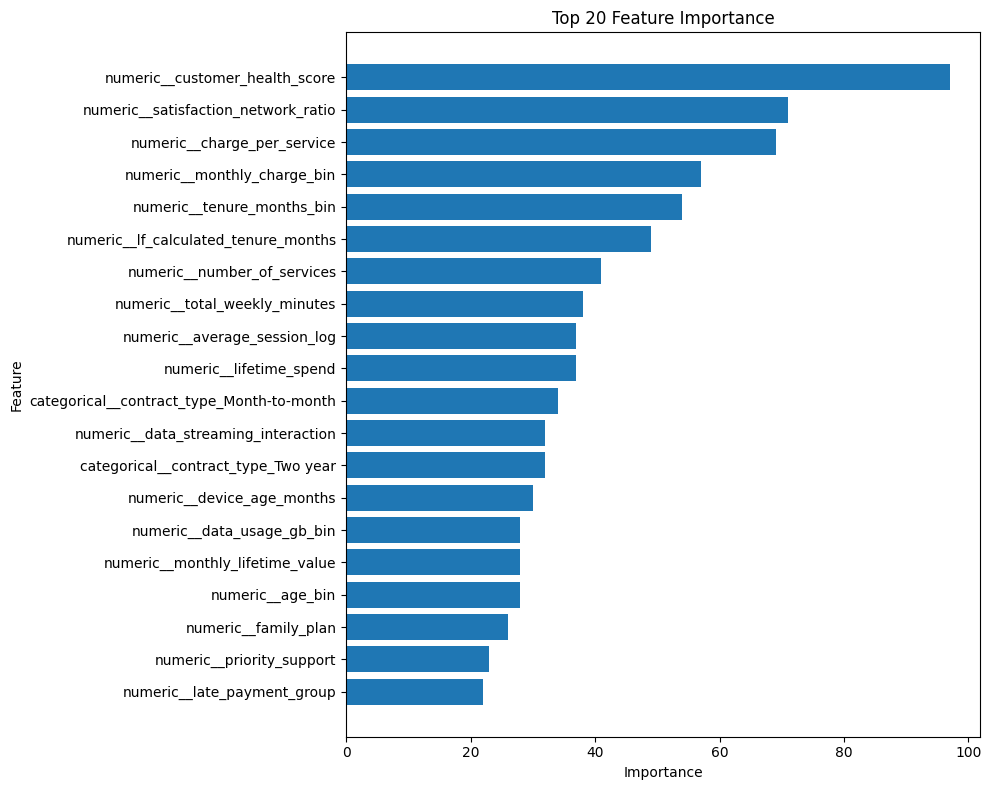

In [47]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance")

plt.tight_layout()
plt.show()

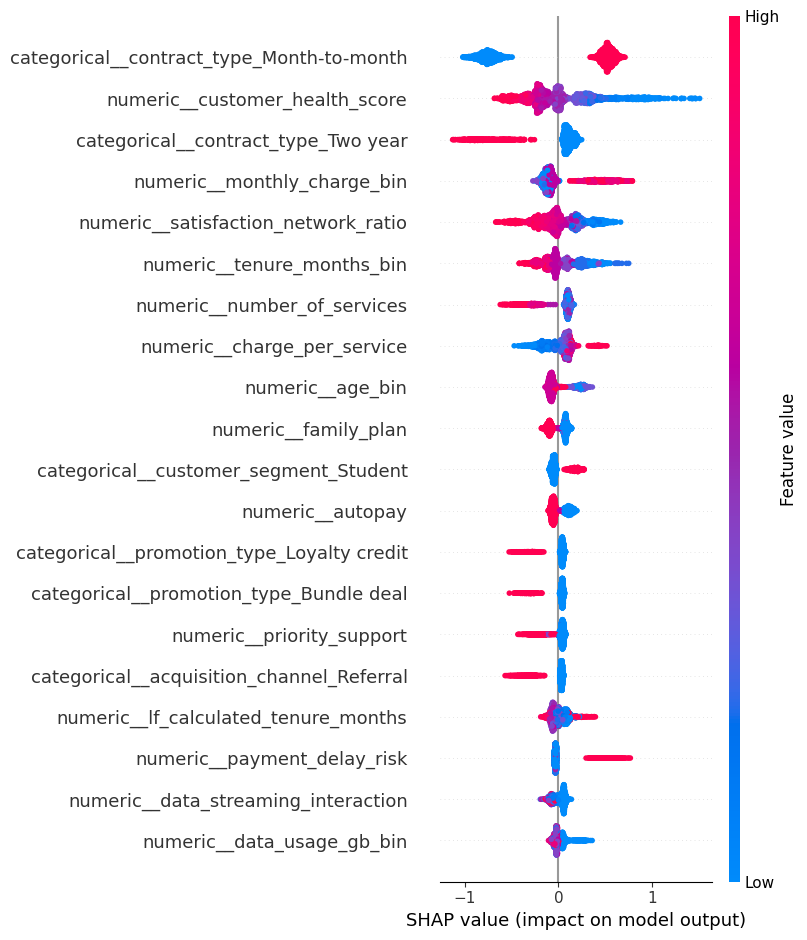

In [48]:
import shap

explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    X_test
)

shap.summary_plot(
    shap_values,
    X_test
)

In [49]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_ABS_SHAP": abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_ABS_SHAP",
    ascending=False
)

print(shap_importance.head(20))

                                       Feature  Mean_ABS_SHAP
50   categorical__contract_type_Month-to-month       0.626799
11              numeric__customer_health_score       0.284327
52         categorical__contract_type_Two year       0.222763
25                 numeric__monthly_charge_bin       0.183308
12         numeric__satisfaction_network_ratio       0.180538
24                  numeric__tenure_months_bin       0.160598
0                  numeric__number_of_services       0.154014
18                 numeric__charge_per_service       0.116911
26                            numeric__age_bin       0.111140
9                         numeric__family_plan       0.086767
39       categorical__customer_segment_Student       0.078613
7                             numeric__autopay       0.075576
76  categorical__promotion_type_Loyalty credit       0.072027
73     categorical__promotion_type_Bundle deal       0.071048
6                    numeric__priority_support       0.069635
47   cat

In [50]:
ranked_features = feature_importance["Feature"].tolist() 
# ranked_features = shap_importance["Feature"].tolist() ## shap_importance

In [51]:
feature_counts = [
    35,
    40,
    45,
    50,
    60,61,62,63,64,65
]

feature_results = []

for n_features in feature_counts:

    selected_features = ranked_features[:n_features]

    X_train_selected = X_train[selected_features]
    X_val_selected = X_test[selected_features]

    model = lgb.LGBMClassifier(
        **lgb_study.best_params,
        objective="binary",
        random_state=42
    )

    model.fit(
        X_train_selected,
        y_train,
        eval_set=[
            (X_val_selected, y_test)
        ],
        callbacks=[
            lgb.early_stopping(
                100,
                verbose=False
            )
        ]
    )

    val_proba = model.predict_proba(
        X_val_selected
    )[:, 1]

    pr_auc = average_precision_score(
        y_test,
        val_proba
    )
    roc_auc = roc_auc_score(y_test, val_proba)


    best_threshold, _ = find_best_threshold(
        y_test,
        val_proba
    )

    feature_results.append({
        "Num_Features": n_features,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Threshold": best_threshold["threshold"],
        "Precision": best_threshold["precision"],
        "Recall": best_threshold["recall"],
        "F1": best_threshold["f1"]
    })

feature_results_df = pd.DataFrame(
    feature_results
)

feature_results_df.sort_values(
    "PR_AUC",
    ascending=False
)

,Num_Features,ROC_AUC,PR_AUC,Threshold,Precision,Recall,F1
3,50,0.807199,0.577688,0.31,0.501285,0.657673,0.568928
8,64,0.808857,0.577053,0.31,0.513583,0.669477,0.581259
0,35,0.807105,0.576708,0.31,0.505236,0.650927,0.568902
4,60,0.808005,0.576212,0.31,0.509881,0.652614,0.572485
6,62,0.806284,0.576111,0.31,0.503218,0.659359,0.570803
2,45,0.807659,0.575792,0.31,0.508453,0.659359,0.574156
7,63,0.809421,0.575739,0.31,0.507134,0.659359,0.573314
1,40,0.808455,0.574680,0.31,0.507246,0.649241,0.569527
9,65,0.807237,0.574677,0.31,0.503896,0.654300,0.569332
5,61,0.806858,0.573554,0.31,0.505852,0.655987,0.571219


In [52]:
best_n_features = 40

selected_features = ranked_features[:best_n_features]

X_train_selected = X_train[selected_features]
X_val_selected = X_test[selected_features]

print("Selected features:", len(selected_features))
print(selected_features)

Selected features: 40
['numeric__customer_health_score', 'numeric__satisfaction_network_ratio', 'numeric__charge_per_service', 'numeric__monthly_charge_bin', 'numeric__tenure_months_bin', 'numeric__lf_calculated_tenure_months', 'numeric__number_of_services', 'numeric__total_weekly_minutes', 'numeric__average_session_log', 'numeric__lifetime_spend', 'categorical__contract_type_Month-to-month', 'numeric__data_streaming_interaction', 'categorical__contract_type_Two year', 'numeric__device_age_months', 'numeric__data_usage_gb_bin', 'numeric__monthly_lifetime_value', 'numeric__age_bin', 'numeric__family_plan', 'numeric__priority_support', 'numeric__late_payment_group', 'numeric__device_age_vs_tenure', 'categorical__acquisition_channel_Referral', 'numeric__payment_delay_risk', 'numeric__autopay', 'categorical__promotion_type_Loyalty credit', 'categorical__customer_segment_Student', 'categorical__promotion_type_Bundle deal', 'numeric__app_sessions_weekly_bin', 'categorical__internet_type_Fibe

In [53]:
final_model = lgb.LGBMClassifier(
    **lgb_study.best_params,
    objective="binary",
    random_state=42
)

final_model.fit(
    X_train_selected,
    y_train,
    eval_set=[(X_val_selected, y_test)],
    callbacks=[
        lgb.early_stopping(
            100,
            verbose=False
        )
    ]
)

,boosting_type,'gbdt'
,num_leaves,62
,max_depth,3
,learning_rate,0.07349312697129345
,n_estimators,875
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,110


In [54]:
val_proba = final_model.predict_proba(
    X_val_selected
)[:, 1]

best_threshold_result, threshold_df = find_best_threshold(
    y_test,
    val_proba
)

print(best_threshold_result)

threshold    0.310000
precision    0.507246
recall       0.649241
f1           0.569527
Name: 3, dtype: float64


### sub

In [57]:
test = fe.fit_transform(X=test)

test_df = fe.drop_columns_init(df_engineered,columns_init_to_drop)

numeric_cols = test_df.select_dtypes(include='number').columns.tolist()
categorical_cols = test_df.select_dtypes(include='object').columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

numeric_features = [
    col for col in numeric_cols
    if col != 'churn'
]

print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_cols))
print(categorical_cols)

test_processed = preprocessor.transform(test_df)

feature_names = preprocessor.get_feature_names_out()

test_processed = pd.DataFrame(
    test_processed,
    columns=feature_names,
    index=test_df.index
)

test_processed = test_processed[selected_features]


Before Shape: (12000, 49)
After Shape: (12000, 49)
Numeric columns:
['number_of_services', 'device_age_months', 'network_complaints', 'referral_count', 'lifetime_spend', 'streaming_service', 'priority_support', 'autopay', 'paperless_billing', 'family_plan', 'international_plan', 'churn', 'customer_health_score', 'satisfaction_network_ratio', 'payment_delay_risk', 'has_payment_delay', 'support_risk', 'high_support_risk', 'network_risk', 'charge_per_service', 'data_streaming_interaction', 'support_network_interaction', 'payment_risk_interaction', 'device_age_vs_tenure', 'monthly_lifetime_value', 'tenure_months_bin', 'monthly_charge_bin', 'age_bin', 'data_usage_gb_bin', 'streaming_hours_monthly_bin', 'device_age_months_bin', 'app_sessions_weekly_bin', 'danger_zone', 'lf_calculated_tenure_months', 'late_payment_group', 'average_session_log', 'total_weekly_minutes']

Categorical columns:
['customer_segment', 'region', 'acquisition_channel', 'contract_type', 'plan_tier', 'internet_type', 'de

In [81]:
test_proba = final_model.predict_proba(test_processed
)[:, 1]

test_pred = (
    test_proba >= threshold
).astype(int)

submission = pd.DataFrame({
    "customer_id": test["customer_id"],
    "churn": test_proba
})

submission.to_csv(
    "submission.csv",
    index=False
)

### apply smote

In [58]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())
current_ratio = y_train.mean() / (1 - y_train.mean())

print("Current ratio:", current_ratio)

target_ratio = max(0.4, current_ratio + 0.01)

smote = SMOTE(
    sampling_strategy=target_ratio,
    random_state=42,
    k_neighbors=5
)


X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nShapes:")
print("Before:", X_train.shape, y_train.shape)
print("After :", X_train_smote.shape, y_train_smote.shape)

Before SMOTE:
churn
0    7230
1    2370
Name: count, dtype: int64
Current ratio: 0.3278008298755187

After SMOTE:
churn
0    7230
1    2892
Name: count, dtype: int64

Shapes:
Before: (9600, 78) (9600,)
After : (10122, 78) (10122,)


In [59]:
lgb_model, lgb_study = tune_lightgbm(
    # X_train,y_train,
    X_train_smote,y_train_smote,
    X_test, y_test,
    n_trials=30
)

models["LightGBM"] = lgb_model

[I 2026-09-27 10:21:01,203] A new study created in memory with name: LightGBM_Fraud
[I 2026-09-27 10:21:02,820] Trial 0 finished with value: 0.569538777761423 and parameters: {'n_estimators': 827, 'learning_rate': 0.021952852404569945, 'num_leaves': 114, 'max_depth': 4, 'min_child_samples': 40, 'subsample': 0.8742556889386813, 'colsample_bytree': 0.8994238460933845, 'reg_alpha': 1.355340577070764e-07, 'reg_lambda': 0.02052679526844039}. Best is trial 0 with value: 0.569538777761423.
[I 2026-09-27 10:21:04,000] Trial 1 finished with value: 0.5660429026798698 and parameters: {'n_estimators': 495, 'learning_rate': 0.01192153885321399, 'num_leaves': 72, 'max_depth': 3, 'min_child_samples': 35, 'subsample': 0.8549657575511882, 'colsample_bytree': 0.693680294481118, 'reg_alpha': 2.4638035738151533e-06, 'reg_lambda': 1.5111145727512982}. Best is trial 0 with value: 0.569538777761423.
[I 2026-09-27 10:21:06,612] Trial 2 finished with value: 0.5602243523904286 and parameters: {'n_estimators': 3

In [ ]:

# xgb_model, xgb_study = tune_xgboost(X_train_smote,y_train_smote,
#     X_test, y_test,
#     n_trials=20
# )

# models["XGBoost"] = xgb_model


# lr_model, lr_study = tune_logistic_regression(X_train_smote,y_train_smote,
#     X_test, y_test,
#     n_trials=20
# )

# models["Logistic Regression"] = lr_model

In [72]:
leaderboard = []

for model_name, model in models.items():

    result = evaluate_model(
        model_name,
        model,
    X_test_processed, y_test,
    )

    leaderboard.append(result)

leaderboard_df = pd.DataFrame(
    leaderboard
)

leaderboard_df = leaderboard_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

# print(leaderboard_df)

In [73]:
leaderboard_df

,Model,PR_AUC,ROC_AUC,Threshold,Precision,Recall,F1
0,LightGBM,0.586325,0.809535,0.31,0.491667,0.696459,0.576413
1,XGBoost,0.587001,0.809509,0.31,0.508564,0.650927,0.571006
2,Logistic Regression,0.545033,0.798892,0.21,0.424189,0.816189,0.558247


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# ============================================
# 1. Train Random Forest
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=8,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight=None,       # SMOTE is already handling imbalance
    random_state=42,
    n_jobs=-1
)

# rf_model.fit(
#     X_train_smote,
#     y_train_smote

# )


rf_model.fit(X_train,y_train)

val_proba = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, val_proba)
print("Roc_auc",roc_auc)
pr_auc = average_precision_score(y_test, val_proba)
print("pr_auc",pr_auc)

threshold_results = []

for threshold in np.arange(0.05, 0.51, 0.01):

    val_pred = (
        val_proba >= threshold
    ).astype(int)

    f1 = f1_score(
        y_test,
        val_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold = threshold_df.loc[
    threshold_df["f1"].idxmax(),
    "threshold"
]

print("Best threshold:", best_threshold)

In [ ]:
import optuna
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score


def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            800,
            step=100
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            5,
            10
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            10
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        ),

        "class_weight": None,

        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    model.fit(
        # X_train_smote,
        # y_train_smote

        X_train,
        y_train
    )

    y_val_proba = model.predict_proba(
        X_test
    )[:, 1]

    pr_auc = average_precision_score(
        y_test,
        y_val_proba
    )

    return pr_auc


study = optuna.create_study(
    direction="maximize",
    study_name="random_forest_fraud"
)

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

In [ ]:
print("Best PR-AUC:")
print(study.best_value)

print("\nBest Parameters:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

In [78]:
import optuna
import numpy as np

from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score


def objective(trial):

    params = {
        "iterations": trial.suggest_int(
            "iterations",
            300,
            1000,
            step=100
        ),

        "depth": trial.suggest_int(
            "depth",
            4,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.15,
            log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            20.0,
            log=True
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0.0,
            5.0
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0.0,
            5.0
        ),

        "border_count": trial.suggest_int(
            "border_count",
            32,
            255
        ),

        "loss_function": "Logloss",
        "eval_metric": "PRAUC",
        "verbose": False,
        "random_seed": 42,
        "thread_count": -1,
        "allow_writing_files": False
    }

    model = CatBoostClassifier(**params)

    model.fit(
        # X_train,
        # y_train,
        X_train_smote,
        y_train_smote,
        # cat_features=categorical_features,
        eval_set=(X_test, y_test),
        early_stopping_rounds=50,
        verbose=False
    )

    y_val_proba = model.predict_proba(
        X_test
    )[:, 1]

    pr_auc = average_precision_score(
        y_test,
        y_val_proba
    )

    return pr_auc

study = optuna.create_study(
    direction="maximize",
    study_name="catboost_fraud"
)

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

[I 2026-09-25 23:44:16,690] A new study created in memory with name: catboost_fraud
  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.564505:   5%|▌         | 1/20 [00:06<02:09,  6.81s/it]

[I 2026-09-25 23:44:23,506] Trial 0 finished with value: 0.5645045122071066 and parameters: {'iterations': 300, 'depth': 8, 'learning_rate': 0.12173387688654869, 'l2_leaf_reg': 2.0766466442882, 'random_strength': 1.0530238573725752, 'bagging_temperature': 2.2279012153544917, 'border_count': 163}. Best is trial 0 with value: 0.5645045122071066.


Best trial: 1. Best value: 0.56596:  10%|█         | 2/20 [00:18<02:55,  9.74s/it] 

[I 2026-09-25 23:44:35,289] Trial 1 finished with value: 0.5659601672923441 and parameters: {'iterations': 400, 'depth': 8, 'learning_rate': 0.025724060339168915, 'l2_leaf_reg': 2.272943567126656, 'random_strength': 4.1255995841169755, 'bagging_temperature': 1.7500697841203579, 'border_count': 57}. Best is trial 1 with value: 0.5659601672923441.


...

[I 2026-09-25 23:47:03,477] Trial 17 finished with value: 0.5742025447331149 and parameters: {'iterations': 800, 'depth': 7, 'learning_rate': 0.025296535077739775, 'l2_leaf_reg': 1.3740623856739553, 'random_strength': 3.262617236786903, 'bagging_temperature': 2.8782948184723693, 'border_count': 77}. Best is trial 5 with value: 0.5844384073993986.


Best trial: 5. Best value: 0.584438:  95%|█████████▌| 19/20 [02:51<00:08,  8.32s/it]

[I 2026-09-25 23:47:08,248] Trial 18 finished with value: 0.5826324767388891 and parameters: {'iterations': 600, 'depth': 5, 'learning_rate': 0.04429241152417993, 'l2_leaf_reg': 9.024695067013498, 'random_strength': 0.6275093291027962, 'bagging_temperature': 0.20604522709232898, 'border_count': 157}. Best is trial 5 with value: 0.5844384073993986.


Best trial: 5. Best value: 0.584438: 100%|██████████| 20/20 [02:53<00:00,  8.68s/it]

[I 2026-09-25 23:47:10,339] Trial 19 finished with value: 0.5790188453530606 and parameters: {'iterations': 500, 'depth': 4, 'learning_rate': 0.08194724478633256, 'l2_leaf_reg': 14.999127617211972, 'random_strength': 0.6282954100513978, 'bagging_temperature': 0.012161536533690093, 'border_count': 161}. Best is trial 5 with value: 0.5844384073993986.


In [77]:
print("Best PR-AUC:")
print(study.best_value)

print("\nBest Parameters:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best PR-AUC:
0.5851343014766346

Best Parameters:
iterations: 1000
depth: 4
learning_rate: 0.05077047279715048
l2_leaf_reg: 1.0877762641369482
random_strength: 2.9586866489302848
bagging_temperature: 1.7993446593608167
border_count: 123
